## LEARNAFRCA STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

learnafrca=pd.read_csv('../stock_data/learnafrca.csv') ## so it can be small letter. This is cool.
learnafrca=learnafrca.drop(columns=['high_price','low_price'])
learnafrca.rename(columns={'trade_date':'date'},inplace=True)
learnafrca['date']=pd.to_datetime(learnafrca['date'])
learnafrca['month']=learnafrca['date'].dt.month
learnafrca['quarter']=learnafrca['date'].dt.quarter
learnafrca['year']=learnafrca['date'].dt.year

learnafrca

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42862,LEARNAFRCA,2017-01-03,0.77,0.77,15000,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43422,LEARNAFRCA,2017-01-04,0.77,0.77,15000,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43532,LEARNAFRCA,2017-01-05,0.77,0.77,0,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43642,LEARNAFRCA,2017-01-06,0.77,0.77,0,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43732,LEARNAFRCA,2017-01-09,0.77,0.77,0,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298084,LEARNAFRCA,2026-07-13,9.00,9.00,194157,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298522,LEARNAFRCA,2026-07-14,9.90,9.90,317733,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298960,LEARNAFRCA,2026-07-15,9.90,9.90,73941,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299398,LEARNAFRCA,2026-07-16,9.90,9.90,1002385,2026-07-16T15:10:03.113936+00:00,7,3,2026


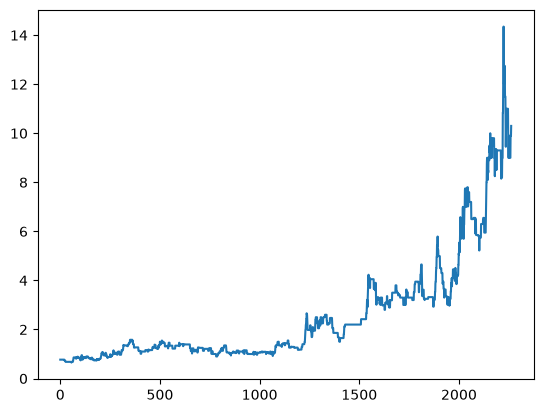

In [2]:
import matplotlib.pyplot as plt

plt.plot(learnafrca['close_price'])
plt.show()

In [3]:
learnafrca_end_month_df = (
    learnafrca
    .sort_values("date")
    .groupby(learnafrca["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

learnafrca_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45432,LEARNAFRCA,2017-01-31,0.77,0.77,4500,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47255,LEARNAFRCA,2017-02-28,0.68,0.68,5555,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49371,LEARNAFRCA,2017-03-31,0.68,0.68,0,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51198,LEARNAFRCA,2017-04-28,0.82,0.82,78512,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53121,LEARNAFRCA,2017-05-31,0.74,0.74,163500,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35321,LEARNAFRCA,2026-03-31,9.30,9.30,237102,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281147,LEARNAFRCA,2026-04-30,9.30,9.30,203682,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284213,LEARNAFRCA,2026-05-29,12.75,12.75,289131,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294141,LEARNAFRCA,2026-06-30,9.00,9.00,64319,2026-06-30T15:10:03.08168+00:00,6,2,2026


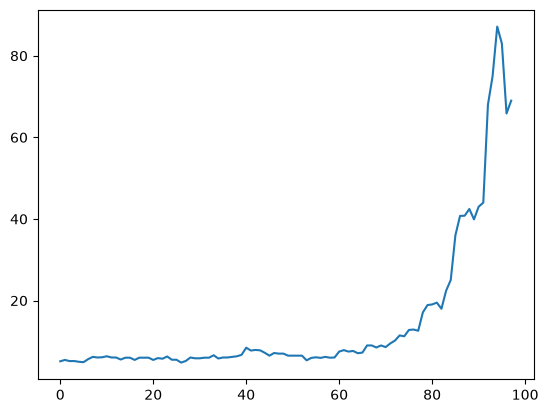

In [ ]:
plt.plot(learnafrca_end_month_df['close_price'])
plt.show()

In [4]:
learnafrca_end_month_df['returns']=learnafrca_end_month_df['close_price'].pct_change()*100
learnafrca_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45432,LEARNAFRCA,2017-01-31,0.77,0.77,4500,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47255,LEARNAFRCA,2017-02-28,0.68,0.68,5555,2026-04-08T02:44:45.006295+00:00,2,1,2017,-11.688312
2,49371,LEARNAFRCA,2017-03-31,0.68,0.68,0,2026-04-08T02:45:42.281198+00:00,3,1,2017,0.000000
3,51198,LEARNAFRCA,2017-04-28,0.82,0.82,78512,2026-04-08T02:51:55.619599+00:00,4,2,2017,20.588235
4,53121,LEARNAFRCA,2017-05-31,0.74,0.74,163500,2026-04-08T02:52:57.421655+00:00,5,2,2017,-9.756098
...,...,...,...,...,...,...,...,...,...,...,...
110,35321,LEARNAFRCA,2026-03-31,9.30,9.30,237102,2026-03-31T15:00:02.085058+00:00,3,1,2026,-2.105263
111,281147,LEARNAFRCA,2026-04-30,9.30,9.30,203682,2026-04-30T15:00:02.170664+00:00,4,2,2026,0.000000
112,284213,LEARNAFRCA,2026-05-29,12.75,12.75,289131,2026-05-29T15:00:02.455558+00:00,5,2,2026,37.096774
113,294141,LEARNAFRCA,2026-06-30,9.00,9.00,64319,2026-06-30T15:10:03.08168+00:00,6,2,2026,-29.411765


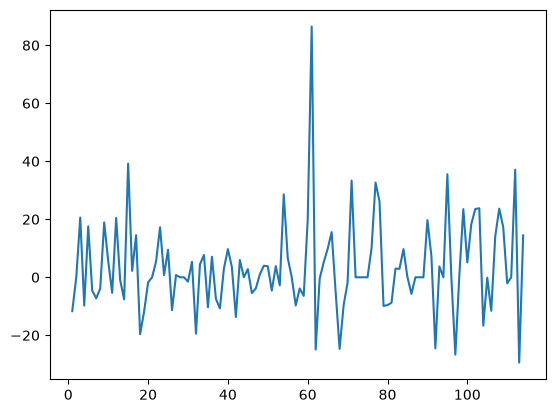

In [5]:
plt.plot(learnafrca_end_month_df['returns'])
plt.show()

In [6]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(learnafrca_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-8.037761952548937), np.float64(1.8825391507768334e-12), 2, 111, {'1%': np.float64(-3.490683082754047), '5%': np.float64(-2.8879516565798817), '10%': np.float64(-2.5808574442009578)}, np.float64(840.5645663542732))
stationary


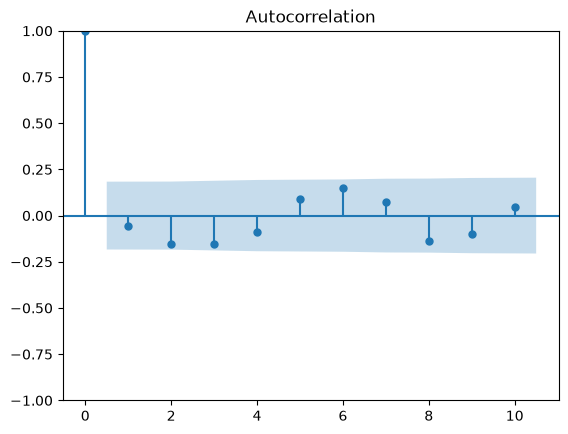

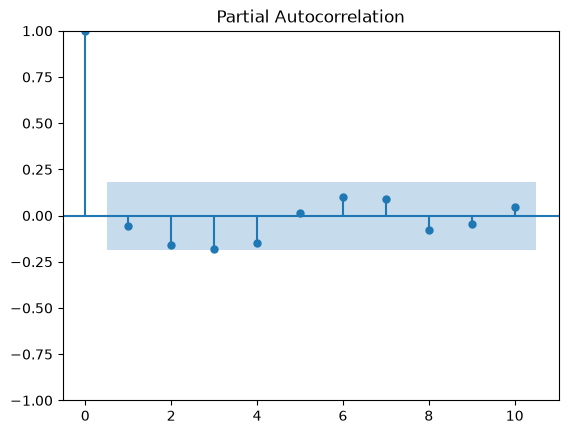

In [7]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(learnafrca_end_month_df['returns'].dropna(), lags=10)
plot_pacf(learnafrca_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [8]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=learnafrca_end_month_df['close_price'][:-10]
test=learnafrca_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -19.400877445306307]
[0, 0, 0, 0, 0, 1, -11.545358678843762]
[0, 0, 0, 0, 0, 2, -7.125867561220787]
[0, 0, 0, 0, 1, 0, -5.064244385525739]
[0, 0, 0, 0, 1, 1, -4.772640662448218]
[0, 0, 0, 0, 1, 2, -4.533472688448914]
[0, 0, 0, 0, 2, 0, -3.572320975570177]
[0, 0, 0, 0, 2, 1, -3.583726036531761]
[0, 0, 0, 0, 2, 2, -3.2033594316028173]
[0, 0, 0, 1, 0, 0, -5.413708001417028]
[0, 0, 0, 1, 0, 1, -5.150969809114019]
[0, 0, 0, 1, 0, 2, -4.951628615690123]
[0, 0, 0, 1, 1, 0, -4.397496615158814]
[0, 0, 0, 1, 1, 1, -4.01017084768869]
[0, 0, 0, 1, 1, 2, -3.7425863171831244]
[0, 0, 0, 1, 2, 0, -3.247841480624478]
[0, 0, 0, 1, 2, 1, -3.3575257792433684]
[0, 0, 0, 1, 2, 2, -3.147940985804957]
[0, 0, 0, 2, 0, 0, -4.855139609400242]
[0, 0, 0, 2, 0, 1, -4.545864212976447]
[0, 0, 0, 2, 0, 2, -4.425574872140329]
[0, 0, 0, 2, 1, 0, -3.784157288140185]
[0, 0, 0, 2, 1, 1, -3.800863086975628]
[0, 0, 0, 2, 1, 2, -3.7608115507892377]
[0, 0, 0, 2, 2, 0, -3.369282297972493]
[0, 0, 0, 2, 2, 1, -

In [9]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
162,0,2,0,0,0,0,-29.025522
163,0,2,0,0,0,1,-21.079319
0,0,0,0,0,0,0,-19.400877
27,0,0,1,0,0,0,-18.882046
173,0,2,0,1,0,2,-18.866612
...,...,...,...,...,...,...,...
660,2,2,0,1,1,0,0.401205
662,2,2,0,1,1,2,0.418503
670,2,2,0,2,1,1,0.419316
661,2,2,0,1,1,1,0.422978


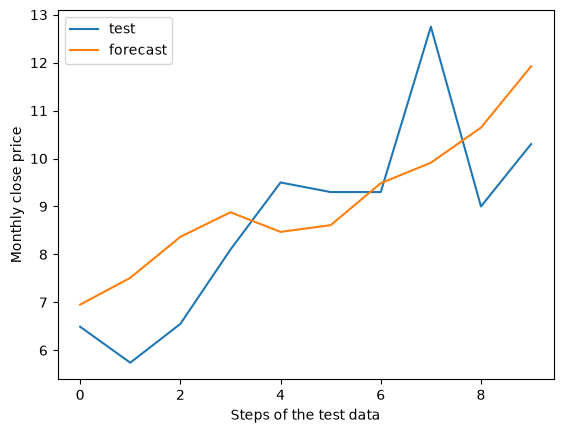

r2_score:  0.43092798614140615
rmse:  1.4905340839768797
description:  count    115.000000
mean       2.620174
std        2.373405
min        0.680000
25%        1.100000
50%        1.440000
75%        3.300000
max       12.750000
Name: close_price, dtype: float64


In [10]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=learnafrca_end_month_df['close_price'][:-10]
y_test=learnafrca_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,2,0), 
seasonal_order=(2,1,2,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', learnafrca_end_month_df.close_price.describe())

We will work with this.